# Phase 3 Step 6 — pct 민감도 실험: 포트폴리오 성능 변화 (`06_pct_sensitivity.ipynb`)

> **목적**: `pct` 파라미터(BL 변동성 양극단 분류 비율, 기본값 0.30)를 0.10~0.40으로 바꿀 때
>          BL 포트폴리오의 Sharpe ratio, 연환산 수익률, Sortino ratio, MDD가 어떻게 변하는지 실험.

## 핵심 설계: Sigma 캐싱으로 실행 시간 최소화

```
Step 1 (§4): 캐싱 루프 — 204 리밸런싱 시점 × LedoitWolf Sigma 추정 (~7분)
             → sigma_cache, pi_cache, mcap_cache, ticker_cache
             → vol_sw_cache, vol_cs_cache, vol_trailing_cache, ew_weights_cache

Step 2 (§5): pct 스윕 — 7개 pct 값 × 204 시점 × [build_P → BL → weights] (~3분)
             → Sigma 재사용으로 LedoitWolf 추가 실행 없음
```

## 실험 파라미터

| 항목 | 값 |
|------|-----|
| `pct` 범위 | 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40 |
| BL 시나리오 | BL_ml_sw, BL_ml_cs (선택), BL_trailing |
| 기준선 | EqualWeight (pct 무관) |
| 평가 메트릭 | Sharpe, 연환산 수익률(%), Sortino ratio, MDD(%) |

## 격리성 보장
- 기존 02a~05 산출물 변경 없음
- 원본 데이터 read-only 접근
- 신규 출력만 `outputs/06_pct_sensitivity/` 에 저장


## §1. 환경 + 설정

In [1]:
%load_ext autoreload
%autoreload 2

import sys, time, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns

from scripts.setup import bootstrap, DATA_DIR, OUTPUTS_DIR
from scripts.black_litterman import (
    compute_pi, build_P, compute_omega, black_litterman, optimize_portfolio,
    Q_FIXED, DEFAULT_TAU, LAM_FIXED,
)
from scripts.covariance import compute_sigma_daily, daily_to_monthly, DAYS_PER_MONTH
from scripts.backtest import backtest_strategy, compute_cumulative_curve
from scripts.benchmarks import equal_weight_portfolio, spy_returns

import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    import koreanize_matplotlib
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

font_used = bootstrap()

# ── 실험 설정 ──
PCT_VALUES = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]  # 탐색할 pct 값
TRANSACTION_COST = 0.0    # 03 노트북과 동일 (무비용 가정)
DAYS_IS = 1260            # Sigma 추정 lookback (5년, 서윤범 99 일관)
MIN_UNIVERSE = 30          # 매월 최소 universe 크기
MIN_VALID_TIX = 20         # IS 데이터 가용 최소 종목 수

OUT_DIR = OUTPUTS_DIR / '06_pct_sensitivity'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 의존 파일 존재 확인 ──
sw_path = DATA_DIR / 'ensemble_predictions_stockwise.csv'
cs_path = DATA_DIR / 'ensemble_predictions_crosssec.csv'

assert sw_path.exists(), f'02a 결과 없음: {sw_path}'
HAS_CS = cs_path.exists()

print(f'BL hyperparameters (서윤범 99 일관):')
print(f'  Q_FIXED={Q_FIXED}, DEFAULT_TAU={DEFAULT_TAU}, LAM_FIXED={LAM_FIXED}')
print(f'  PCT_VALUES={PCT_VALUES}')
print(f'  BL_ml_cs 사용 가능: {HAS_CS}')
print(f'  출력 경로: {OUT_DIR}')

  Phase 3 Robust Extensions — 환경 부트스트랩 완료
  한글 폰트   : Malgun Gothic
  시드        : 42
  데이터 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data
  Phase 1.5  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility
  Phase 2    : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration
BL hyperparameters (서윤범 99 일관):
  Q_FIXED=0.003, DEFAULT_TAU=0.1, LAM_FIXED=2.5
  PCT_VALUES=[0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
  BL_ml_cs 사용 가능: True
  출력 경로: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\06_pct_sensitivity


## §2. 데이터 로드 (03 노트북 §2와 동일 패턴)

In [2]:
# 2-1. universe
universe = pd.read_csv(
    DATA_DIR / 'universe_full_history.csv', parse_dates=['cutoff_date']
)
print(f'universe: {universe.shape}, {universe["ticker"].nunique()} 종목')

# 2-2. daily_panel (필요 컬럼만 로드)
panel = pd.read_csv(
    DATA_DIR / 'daily_panel.csv', parse_dates=['date'],
    usecols=['date', 'ticker', 'log_ret', 'vol_21d', 'mcap_value',
             'spy_close', 'rf_daily'],
)
panel['date'] = pd.to_datetime(panel['date'])
print(f'panel: {panel.shape}, {panel["ticker"].nunique()} 종목')

# 2-3. 02a ensemble (필수)
ens_sw = pd.read_csv(sw_path, parse_dates=['date'])
print(f'ensemble_sw: {ens_sw.shape} ({ens_sw["ticker"].nunique()} 종목)')

# 2-4. 02b CS ensemble (선택)
if HAS_CS:
    ens_cs = pd.read_csv(cs_path, parse_dates=['date'])
    print(f'ensemble_cs: {ens_cs.shape} ({ens_cs["ticker"].nunique()} 종목)')
else:
    ens_cs = None
    print('ensemble_cs: 없음 (02b 학습 완료 후 재실행하면 BL_ml_cs 추가)')

# 2-5. market data
market = pd.read_csv(DATA_DIR / 'market_data.csv', index_col='date', parse_dates=True)
print(f'market: {market.shape}')

# 2-6. 학습된 종목 set
trained_tickers_sw = set(ens_sw['ticker'].unique())
trained_tickers_cs = set(ens_cs['ticker'].unique()) if HAS_CS else set()
trained_tickers = trained_tickers_sw  # BL universe 필터 기준 (서윤범 일관)
print(f'\n학습 종목: sw={len(trained_tickers_sw)}, '
      f'cs={len(trained_tickers_cs)}, 교집합={len(trained_tickers_sw & trained_tickers_cs)}')

universe: (809, 6), 809 종목
panel: (3395442, 7), 646 종목
ensemble_sw: (2468883, 9) (613 종목)
ensemble_cs: (2635610, 9) (615 종목)
market: (6122, 3)

학습 종목: sw=613, cs=615, 교집합=613


## §3. 헬퍼 함수

In [3]:
# ─── 3-1. daily log_ret pivot ───
daily_lr = panel.pivot_table(index='date', columns='ticker', values='log_ret')
print(f'daily_lr: {daily_lr.shape}')

# ─── 3-2. 리밸런싱 시점 (market 거래일 월말, Phase 2 Issue #1 일관) ───
market_lastday_per_month = market.groupby(market.index.to_period('M')).tail(1)
rebalance_dates = market_lastday_per_month.index
rebalance_dates = rebalance_dates[
    (rebalance_dates >= '2009-01-01') & (rebalance_dates <= '2025-12-31')
]
month_to_market_eom = {pd.Timestamp(d).to_period('M'): pd.Timestamp(d)
                       for d in rebalance_dates}
print(f'rebalance_dates: {len(rebalance_dates)} 개월 '
      f'({rebalance_dates[0].date()} ~ {rebalance_dates[-1].date()})')

# ─── 3-3. 월별 수익률 계산 ───
def compute_monthly_returns(panel_df, tickers, start_date, end_date, month_to_eom=None):
    """종목별 월별 단순 수익률 (market eom index 사용, Issue #1B 일관)."""
    sub = panel_df[
        panel_df['ticker'].isin(tickers) &
        (panel_df['date'] >= start_date) & (panel_df['date'] <= end_date)
    ].set_index('date')
    sub['month'] = sub.index.to_period('M')
    monthly_lr = sub.groupby(['ticker', 'month'])['log_ret'].sum().reset_index()
    if month_to_eom is not None:
        monthly_lr['date'] = monthly_lr['month'].map(month_to_eom)
        monthly_lr = monthly_lr.dropna(subset=['date'])
    else:
        monthly_lr['date'] = monthly_lr['month'].dt.to_timestamp(how='end').dt.normalize()
    monthly_lr['ret'] = np.exp(monthly_lr['log_ret']) - 1
    return monthly_lr.pivot_table(index='date', columns='ticker', values='ret')

# ─── 3-4. mcap 취득 ───
def get_mcap(panel_df, date, tickers):
    sub = panel_df[(panel_df['date'] <= date) & panel_df['ticker'].isin(tickers)]
    return sub.sort_values(['ticker', 'date']).groupby('ticker').last()['mcap_value'].dropna()

# ─── 3-5. SPY monthly + rf ───
spy_prices = market['SPY']
spy_daily = spy_prices.pct_change().dropna()
rf_daily = panel.groupby('date')['rf_daily'].mean()

spy_lr = np.log(1 + spy_daily)
rf_lr = rf_daily.reindex(spy_lr.index, method='ffill').fillna(0)

# Issue #2 일관: spy_excess = spy - rf (월별 환산)
spy_excess_monthly = float((spy_lr - rf_lr).mean() * DAYS_PER_MONTH)
spy_sigma2_monthly = float(spy_lr.var() * DAYS_PER_MONTH)
print(f'spy_excess_monthly: {spy_excess_monthly:.6f}')
print(f'spy_sigma2_monthly: {spy_sigma2_monthly:.6f}')

# ─── 3-6. ensemble → 월별 예측 피벗 ───
def get_monthly_pred(ens_df, pred_col='y_pred_ensemble'):
    """ensemble DataFrame → 리밸런싱 시점 기준 종목별 예측 피벗."""
    ens_copy = ens_df.copy()
    ens_copy['month'] = ens_copy['date'].dt.to_period('M')
    monthly = ens_copy.groupby(['ticker', 'month'])[pred_col].last().reset_index()
    monthly['rebalance_date'] = monthly['month'].map(month_to_market_eom)
    monthly = monthly.dropna(subset=['rebalance_date'])
    return monthly.pivot_table(index='rebalance_date', columns='ticker', values=pred_col)

sw_pred_col = 'y_pred_ensemble'
monthly_pred_sw = get_monthly_pred(ens_sw, sw_pred_col)
print(f'monthly_pred_sw: {monthly_pred_sw.shape}')

if HAS_CS:
    cs_pred_col = ('y_pred_ensemble' if 'y_pred_ensemble' in ens_cs.columns
                   else 'y_pred_lstm_cs')
    monthly_pred_cs = get_monthly_pred(ens_cs, cs_pred_col)
    print(f'monthly_pred_cs: {monthly_pred_cs.shape}')
else:
    monthly_pred_cs = None

daily_lr: (6120, 646)
rebalance_dates: 204 개월 (2009-01-30 ~ 2025-12-31)
spy_excess_monthly: 0.006454
spy_sigma2_monthly: 0.003012
monthly_pred_sw: (204, 613)
monthly_pred_cs: (204, 615)


In [4]:
# ─── 3-7. 확장 메트릭 계산 함수 (Sharpe + Sortino + MDD + CAGR) ───
def compute_metrics_extended(rets, annual_factor=12):
    """Sharpe, annual_ret, Sortino, MDD, CAGR 포함 메트릭 계산 (rf=0 가정).

    Sortino ratio 계산:
        - MAR(최소 수용 수익률) = 0 (rf≈0 가정)
        - 하방 편차 = 음수 수익 구간의 표준편차 × sqrt(annual_factor)
        - Sortino = 연환산 수익 / 하방 편차
    """
    if len(rets) == 0:
        return {k: np.nan for k in
                ['sharpe', 'annual_ret', 'ann_vol', 'sortino', 'mdd', 'cagr', 'n_months']}

    ann_ret = rets.mean() * annual_factor
    ann_vol = rets.std() * np.sqrt(annual_factor)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan

    # Sortino: 하방 편차 = 음수 수익만 표준편차 (MAR=0)
    downside = rets[rets < 0]
    if len(downside) >= 2:
        downside_std = downside.std() * np.sqrt(annual_factor)
        sortino = ann_ret / downside_std if downside_std > 0 else np.nan
    else:
        sortino = np.nan  # 하방 데이터 부족

    cum = (1 + rets).cumprod()
    mdd = float(((cum / cum.cummax()) - 1).min())
    n = len(rets)
    cagr = float(cum.iloc[-1] ** (annual_factor / n) - 1) if n > 0 else np.nan

    return {
        'sharpe':     float(sharpe),
        'annual_ret': float(ann_ret * 100),   # %
        'ann_vol':    float(ann_vol * 100),   # %
        'sortino':    float(sortino),
        'mdd':        float(mdd * 100),       # % (음수)
        'cagr':       float(cagr * 100),      # %
        'n_months':   n,
    }

## §4. Step 1: Sigma 사전 캐싱 (핵심 최적화)

LedoitWolf Sigma 추정은 pct와 무관 → 204 리밸런싱 시점에서 **1회만** 실행 후 캐싱.
pct 루프(§5)에서는 build_P / BL / weights 만 반복 (Sigma 재사용).


In [5]:
# ─── 사전 캐시 dict 초기화 ───
sigma_cache    = {}   # {date: Sigma_c (DataFrame)}
pi_cache       = {}   # {date: (pi Series, lam float)}
mcap_cache     = {}   # {date: mcap_c Series}
ticker_cache   = {}   # {date: common_tickers list}
vol_sw_cache   = {}   # {date: vol_sw_actual Series} — log-RV → exp 환산
vol_cs_cache   = {}   # {date: vol_cs_actual Series}
vol_trail_cache = {}  # {date: vol_trailing Series}
ew_cache       = {}   # {date: EqualWeight pd.Series} — pct 무관이므로 여기서 계산

skip_log = {}         # 건너뛴 시점 기록

print(f'리밸런싱 시점 총 {len(rebalance_dates)} 개월')
print('Sigma 캐싱 시작 (LedoitWolf × 204 회 예상, ~7분)...')
t0 = time.time()

for i, reb_date in enumerate(rebalance_dates):

    # ── universe 결정 (03 노트북 §4와 동일 로직) ──
    panel_at_date = panel[panel['date'] == reb_date].dropna(
        subset=['vol_21d', 'mcap_value', 'log_ret']
    )
    panel_tickers_at_date = set(panel_at_date['ticker'])
    available_tickers = panel_tickers_at_date & trained_tickers  # 학습된 종목만
    if len(available_tickers) < MIN_UNIVERSE:
        skip_log[reb_date] = f'panel∩trained<{MIN_UNIVERSE} ({len(available_tickers)})'
        continue
    tickers = sorted(available_tickers)

    # ── IS 기간 데이터 슬라이싱 ──
    is_end   = reb_date
    is_start = is_end - pd.offsets.BDay(DAYS_IS)
    is_data  = daily_lr.loc[is_start:is_end, :]

    avail_tickers = [
        t for t in tickers
        if t in is_data.columns
        and is_data[t].notna().sum() >= int(DAYS_IS * 0.7)  # 70% 이상 가용
    ]
    if len(avail_tickers) < MIN_VALID_TIX:
        skip_log[reb_date] = f'valid_tix<{MIN_VALID_TIX} ({len(avail_tickers)})'
        continue

    # ── Sigma 추정 (LedoitWolf, 1회만 실행) ──
    # estimate_covariance()는 is_start/is_end 인자가 필수이므로,
    # 이미 슬라이싱된 배열에 compute_sigma_daily + daily_to_monthly 직접 호출
    try:
        sub = is_data[avail_tickers].dropna()
        Sigma = daily_to_monthly(compute_sigma_daily(sub))
    except Exception as e:
        skip_log[reb_date] = f'Sigma fail: {str(e)[:60]}'
        continue

    # ── mcap + BL 사전 입력 계산 ──
    mcap = get_mcap(panel, reb_date, avail_tickers)
    common_tickers = list(Sigma.index.intersection(mcap.index))
    if len(common_tickers) < MIN_VALID_TIX:
        skip_log[reb_date] = f'common_tix<{MIN_VALID_TIX} ({len(common_tickers)})'
        continue

    Sigma_c = Sigma.loc[common_tickers, common_tickers]
    mcap_c  = mcap[common_tickers]
    w_mkt   = mcap_c / mcap_c.sum()

    pi, lam = compute_pi(Sigma_c, w_mkt, spy_excess_monthly, spy_sigma2_monthly,
                         lam_fixed=LAM_FIXED)

    # ── 변동성 시리즈 캐싱 (build_P 호출 이전 단계) ──

    # BL_ml_sw: log-RV 예측 → exp 로 실제 변동성 수준 환산
    if reb_date in monthly_pred_sw.index:
        vol_sw = monthly_pred_sw.loc[reb_date].reindex(common_tickers)
        vol_sw_cache[reb_date] = np.exp(vol_sw).fillna(vol_sw.median())

    # BL_ml_cs (선택)
    if HAS_CS and reb_date in monthly_pred_cs.index:
        vol_cs = monthly_pred_cs.loc[reb_date].reindex(common_tickers)
        vol_cs_cache[reb_date] = np.exp(vol_cs).fillna(vol_cs.median())

    # BL_trailing: trailing vol_21d
    vol_trail = panel[
        (panel['date'] == reb_date) & (panel['ticker'].isin(common_tickers))
    ].set_index('ticker')['vol_21d']
    if vol_trail.notna().sum() >= 5:
        vol_trail_cache[reb_date] = vol_trail.reindex(common_tickers).fillna(vol_trail.median())

    # EqualWeight (pct 무관 — 한 번만 계산)
    ew_cache[reb_date] = equal_weight_portfolio(common_tickers)

    # ── 캐시 저장 ──
    sigma_cache[reb_date]  = Sigma_c
    pi_cache[reb_date]     = (pi, lam)
    mcap_cache[reb_date]   = mcap_c
    ticker_cache[reb_date] = common_tickers

    if (i + 1) % 24 == 0:
        elapsed = time.time() - t0
        print(f'  [{i+1:3d}/{len(rebalance_dates)}] {reb_date.date()}: '
              f'{len(sigma_cache)} 캐시 저장, {elapsed:.0f}초 경과')

elapsed_total = time.time() - t0
print(f'\n캐싱 완료: {len(sigma_cache)} 개월 캐시 | {elapsed_total:.1f}초')
print(f'  - vol_sw_cache: {len(vol_sw_cache)} 시점')
print(f'  - vol_cs_cache: {len(vol_cs_cache)} 시점 (HAS_CS={HAS_CS})')
print(f'  - vol_trail_cache: {len(vol_trail_cache)} 시점')
print(f'  - ew_cache: {len(ew_cache)} 시점')
if skip_log:
    from collections import Counter
    reasons = Counter(v.split('<')[0] for v in skip_log.values())
    print(f'  - skip: {len(skip_log)} 시점 {dict(reasons)}')

리밸런싱 시점 총 204 개월
Sigma 캐싱 시작 (LedoitWolf × 204 회 예상, ~7분)...
  [ 24/204] 2010-12-31: 24 캐시 저장, 11초 경과
  [ 48/204] 2012-12-31: 48 캐시 저장, 23초 경과
  [ 72/204] 2014-12-31: 72 캐시 저장, 36초 경과
  [ 96/204] 2016-12-30: 96 캐시 저장, 50초 경과
  [120/204] 2018-12-31: 120 캐시 저장, 66초 경과
  [144/204] 2020-12-31: 144 캐시 저장, 83초 경과
  [168/204] 2022-12-30: 168 캐시 저장, 100초 경과
  [192/204] 2024-12-31: 192 캐시 저장, 120초 경과

캐싱 완료: 204 개월 캐시 | 130.5초
  - vol_sw_cache: 204 시점
  - vol_cs_cache: 204 시점 (HAS_CS=True)
  - vol_trail_cache: 204 시점
  - ew_cache: 204 시점


## §5. Step 2: pct 스윕 (Sigma 재사용, 빠름)

캐싱된 Sigma / pi / mcap / vol 을 재사용하여 각 pct 값으로 build_P → BL → weights 재계산.
LedoitWolf 추가 실행 없음 → 전체 7회 × 204시점 = 1,428회 경량 BL 계산만 수행.


In [6]:
# ─── 월별 수익률 행렬 (backtest_strategy 입력용) ───
all_tickers_union = universe['ticker'].unique().tolist()
monthly_rets = compute_monthly_returns(
    panel, all_tickers_union,
    start_date='2009-01-01', end_date='2025-12-31',
    month_to_eom=month_to_market_eom,
)
# forward_rets: 현재 가중치 → 다음 달 수익률
forward_rets = monthly_rets.shift(-1)
print(f'monthly_rets: {monthly_rets.shape}')
print(f'forward_rets: {forward_rets.shape}')

# ─── SPY 수익률 (기준선) ───
spy_ret = spy_returns(market, rebalance_dates, return_type='monthly').dropna()
print(f'SPY: {len(spy_ret)} 개월')

monthly_rets: (204, 646)
forward_rets: (204, 646)
SPY: 203 개월


In [7]:
# ─── pct 스윕 메인 루프 ───
# pct_results[pct_val][scenario] = pd.Series (월별 수익률)
pct_results = {}

print(f'pct 스윕 시작: {PCT_VALUES}')
print(f'Sigma 재사용 — 추가 LedoitWolf 없음')
t0 = time.time()

for pct_val in PCT_VALUES:
    pct_str = f'{pct_val:.2f}'

    # 시나리오별 가중치 dict 초기화
    w_bl_sw    = {}   # BL_ml_sw
    w_bl_cs    = {}   # BL_ml_cs (HAS_CS 시)
    w_bl_trail = {}   # BL_trailing

    for reb_date, Sigma_c in sigma_cache.items():
        pi, lam           = pi_cache[reb_date]
        mcap_c            = mcap_cache[reb_date]
        common_tickers    = ticker_cache[reb_date]

        # ── BL_ml_sw ──
        if reb_date in vol_sw_cache:
            vol_sw_actual = vol_sw_cache[reb_date]
            valid = vol_sw_actual.dropna()
            if len(valid) >= max(2, int(len(common_tickers) * pct_val)):
                try:
                    P_sw = build_P(valid, mcap_c[valid.index], pct=pct_val)
                    P_sw = P_sw.reindex(common_tickers).fillna(0)
                    omega_sw = compute_omega(P_sw, Sigma_c, DEFAULT_TAU)
                    mu_bl_sw = black_litterman(pi, Sigma_c, P_sw, Q_FIXED, omega_sw, DEFAULT_TAU)
                    w_bl_sw[reb_date] = optimize_portfolio(mu_bl_sw, Sigma_c, lam)
                except Exception:
                    pass

        # ── BL_ml_cs (선택) ──
        if HAS_CS and reb_date in vol_cs_cache:
            vol_cs_actual = vol_cs_cache[reb_date]
            valid_cs = vol_cs_actual.dropna()
            if len(valid_cs) >= max(2, int(len(common_tickers) * pct_val)):
                try:
                    P_cs = build_P(valid_cs, mcap_c[valid_cs.index], pct=pct_val)
                    P_cs = P_cs.reindex(common_tickers).fillna(0)
                    omega_cs = compute_omega(P_cs, Sigma_c, DEFAULT_TAU)
                    mu_bl_cs = black_litterman(pi, Sigma_c, P_cs, Q_FIXED, omega_cs, DEFAULT_TAU)
                    w_bl_cs[reb_date] = optimize_portfolio(mu_bl_cs, Sigma_c, lam)
                except Exception:
                    pass

        # ── BL_trailing ──
        if reb_date in vol_trail_cache:
            vol_t = vol_trail_cache[reb_date]
            if vol_t.notna().sum() >= max(2, int(len(common_tickers) * pct_val)):
                try:
                    P_t = build_P(vol_t.dropna(), mcap_c[vol_t.dropna().index], pct=pct_val)
                    P_t = P_t.reindex(common_tickers).fillna(0)
                    omega_t = compute_omega(P_t, Sigma_c, DEFAULT_TAU)
                    mu_bl_t = black_litterman(pi, Sigma_c, P_t, Q_FIXED, omega_t, DEFAULT_TAU)
                    w_bl_trail[reb_date] = optimize_portfolio(mu_bl_t, Sigma_c, lam)
                except Exception:
                    pass

    # ── backtest_strategy 호출 ──
    pct_port = {}

    for s_name, w_dict in [('BL_ml_sw', w_bl_sw), ('BL_trailing', w_bl_trail)]:
        if len(w_dict) == 0:
            continue
        wdf = pd.DataFrame(w_dict).T.fillna(0)
        ret = backtest_strategy(wdf, forward_rets, TRANSACTION_COST)
        pct_port[s_name] = ret.dropna()

    if HAS_CS and len(w_bl_cs) > 0:
        wdf_cs = pd.DataFrame(w_bl_cs).T.fillna(0)
        ret_cs = backtest_strategy(wdf_cs, forward_rets, TRANSACTION_COST)
        pct_port['BL_ml_cs'] = ret_cs.dropna()

    # EqualWeight: pct 무관 (ew_cache 재사용)
    wdf_ew = pd.DataFrame(ew_cache).T.fillna(0)
    ret_ew = backtest_strategy(wdf_ew, forward_rets, TRANSACTION_COST)
    pct_port['EqualWeight'] = ret_ew.dropna()

    pct_results[pct_val] = pct_port
    print(f'  pct={pct_str}: {", ".join(f"{s}={len(r)}개월" for s, r in pct_port.items())}')

print(f'\n스윕 완료: {time.time()-t0:.1f}초')

pct 스윕 시작: [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
Sigma 재사용 — 추가 LedoitWolf 없음
  pct=0.10: BL_ml_sw=204개월, BL_trailing=204개월, BL_ml_cs=204개월, EqualWeight=204개월
  pct=0.15: BL_ml_sw=204개월, BL_trailing=204개월, BL_ml_cs=204개월, EqualWeight=204개월
  pct=0.20: BL_ml_sw=204개월, BL_trailing=204개월, BL_ml_cs=204개월, EqualWeight=204개월
  pct=0.25: BL_ml_sw=204개월, BL_trailing=204개월, BL_ml_cs=204개월, EqualWeight=204개월
  pct=0.30: BL_ml_sw=204개월, BL_trailing=204개월, BL_ml_cs=204개월, EqualWeight=204개월
  pct=0.35: BL_ml_sw=204개월, BL_trailing=204개월, BL_ml_cs=204개월, EqualWeight=204개월
  pct=0.40: BL_ml_sw=204개월, BL_trailing=204개월, BL_ml_cs=204개월, EqualWeight=204개월

스윕 완료: 17477.1초


## §6. 메트릭 집계 + Fair 비교 테이블

**Fair 비교 기준**: BL_ml_sw (또는 BL_trailing) 의 가용 기간으로 모든 시나리오 통일.


In [8]:
# ─── Fair 비교 기준 기간 결정 (pct=0.30 기준 — 기본값) ───
base_pct = 0.30
base_scenario = 'BL_ml_sw' if 'BL_ml_sw' in pct_results[base_pct] else 'BL_trailing'
common_dates = pct_results[base_pct][base_scenario].index
print(f'Fair 비교 기준: pct={base_pct}, 시나리오={base_scenario}')
print(f'공통 기간: {common_dates[0].date()} ~ {common_dates[-1].date()} ({len(common_dates)} 개월)')

# ─── 메트릭 계산 (모든 pct × 시나리오) ───
records = []
fair_returns = {}   # {(pct_val, scenario): pd.Series} — 시각화용

for pct_val, port_dict in pct_results.items():
    fair_returns[pct_val] = {}
    for scenario, rets in port_dict.items():
        rets_fair = rets.reindex(common_dates).dropna()
        fair_returns[pct_val][scenario] = rets_fair
        m = compute_metrics_extended(rets_fair)
        m['pct']      = pct_val
        m['scenario'] = scenario
        records.append(m)

# SPY는 pct 무관 — 한 번만 계산
spy_fair = spy_ret.reindex(common_dates).dropna()
spy_metrics = compute_metrics_extended(spy_fair)
spy_metrics['pct'] = 'all'
spy_metrics['scenario'] = 'SPY'
records.append(spy_metrics)

metrics_long = pd.DataFrame(records)
print(f'\n총 메트릭 행: {len(metrics_long)} '
      f'(= {len(PCT_VALUES)} pct × 시나리오 수 + SPY 1개)')

Fair 비교 기준: pct=0.3, 시나리오=BL_ml_sw
공통 기간: 2009-01-30 ~ 2025-12-31 (204 개월)

총 메트릭 행: 29 (= 7 pct × 시나리오 수 + SPY 1개)


In [9]:
# ─── 결과 테이블 출력 ───
METRICS_ORDER = ['sharpe', 'annual_ret', 'sortino', 'mdd', 'cagr', 'n_months']
METRIC_LABELS = {
    'sharpe':     'Sharpe',
    'annual_ret': 'Ann. Ret.(%)',
    'ann_vol':    'Ann. Vol.(%)',
    'sortino':    'Sortino',
    'mdd':        'MDD(%)',
    'cagr':       'CAGR(%)',
    'n_months':   'N (월)',
}

# 시나리오 목록 (SPY 제외)
bl_scenarios = [s for s in ['BL_ml_sw', 'BL_ml_cs', 'BL_trailing', 'EqualWeight']
                if s in metrics_long['scenario'].values]

for scenario in bl_scenarios:
    sub = metrics_long[metrics_long['scenario'] == scenario].copy()
    sub = sub.sort_values('pct')
    sub = sub.set_index('pct')[['sharpe', 'annual_ret', 'sortino', 'mdd', 'cagr']]
    sub.columns = [METRIC_LABELS.get(c, c) for c in sub.columns]
    print(f'\n=== {scenario} ===')
    print(sub.round(3).to_string())

print(f'\n=== SPY (기준선, pct 무관) ===')
spy_row = metrics_long[metrics_long['scenario'] == 'SPY'].iloc[0]
print(f'  Sharpe={spy_row["sharpe"]:.3f}, Ann.Ret={spy_row["annual_ret"]:.2f}%, '
      f'Sortino={spy_row["sortino"]:.3f}, MDD={spy_row["mdd"]:.2f}%, CAGR={spy_row["cagr"]:.2f}%')

# Sharpe 피벗 (빠른 비교)
print('\n=== Sharpe ratio 요약 (시나리오 × pct) ===')
pivot_sharpe = metrics_long[metrics_long['pct'] != 'all'].pivot_table(
    index='scenario', columns='pct', values='sharpe'
)
print(pivot_sharpe.round(3).to_string())
print(f'\n★ 현행 기본값 pct=0.30 컬럼과 비교하여 최적 pct 탐색')


=== BL_ml_sw ===
           Sharpe  Ann. Ret.(%)  Sortino     MDD(%)   CAGR(%)
pct                                                          
0.100000 1.113000     13.783000 1.676000 -19.921000 13.828000
0.150000 1.130000     13.892000 1.752000 -18.744000 13.966000
0.200000 1.113000     13.428000 1.731000 -18.253000 13.474000
0.250000 1.114000     13.531000 1.710000 -18.272000 13.580000
0.300000 1.091000     13.393000 1.667000 -18.856000 13.408000
0.350000 1.101000     13.521000 1.694000 -19.029000 13.551000
0.400000 1.108000     13.592000 1.709000 -18.602000 13.635000

=== BL_ml_cs ===
           Sharpe  Ann. Ret.(%)  Sortino     MDD(%)   CAGR(%)
pct                                                          
0.100000 1.190000     14.377000 1.709000 -19.230000 14.535000
0.150000 1.188000     13.895000 1.690000 -18.832000 14.043000
0.200000 1.171000     13.590000 1.669000 -18.195000 13.711000
0.250000 1.161000     13.452000 1.675000 -18.582000 13.559000
0.300000 1.152000     13.337000 1.

In [10]:
# ─── 시나리오별 최적 pct (Sharpe 기준) ───
print('\n=== Sharpe 기준 최적 pct (시나리오별) ===')
optimal_pct = {}
for scenario in bl_scenarios:
    sub = metrics_long[
        (metrics_long['scenario'] == scenario) & (metrics_long['pct'] != 'all')
    ]
    if len(sub) == 0:
        continue
    best_row = sub.loc[sub['sharpe'].idxmax()]
    optimal_pct[scenario] = {
        'pct': float(best_row['pct']),
        'sharpe': float(best_row['sharpe']),
        'annual_ret': float(best_row['annual_ret']),
        'sortino': float(best_row['sortino']),
    }
    baseline_sharpe = sub[sub['pct'] == base_pct]['sharpe'].values
    baseline_str = f'{baseline_sharpe[0]:.3f}' if len(baseline_sharpe) > 0 else 'N/A'
    print(f'  {scenario}: 최적 pct={best_row["pct"]:.2f} '
          f'(Sharpe={best_row["sharpe"]:.3f}) | pct=0.30 기준={baseline_str}')


=== Sharpe 기준 최적 pct (시나리오별) ===
  BL_ml_sw: 최적 pct=0.15 (Sharpe=1.130) | pct=0.30 기준=1.091
  BL_ml_cs: 최적 pct=0.40 (Sharpe=1.201) | pct=0.30 기준=1.152
  BL_trailing: 최적 pct=0.20 (Sharpe=1.252) | pct=0.30 기준=1.234
  EqualWeight: 최적 pct=0.10 (Sharpe=1.133) | pct=0.30 기준=1.133


## §7. 시각화

### Figure 1: 메트릭 vs pct (2×2 패널)
### Figure 2: 선택 pct 누적 수익률 비교
### Figure 3: Sharpe ratio 히트맵


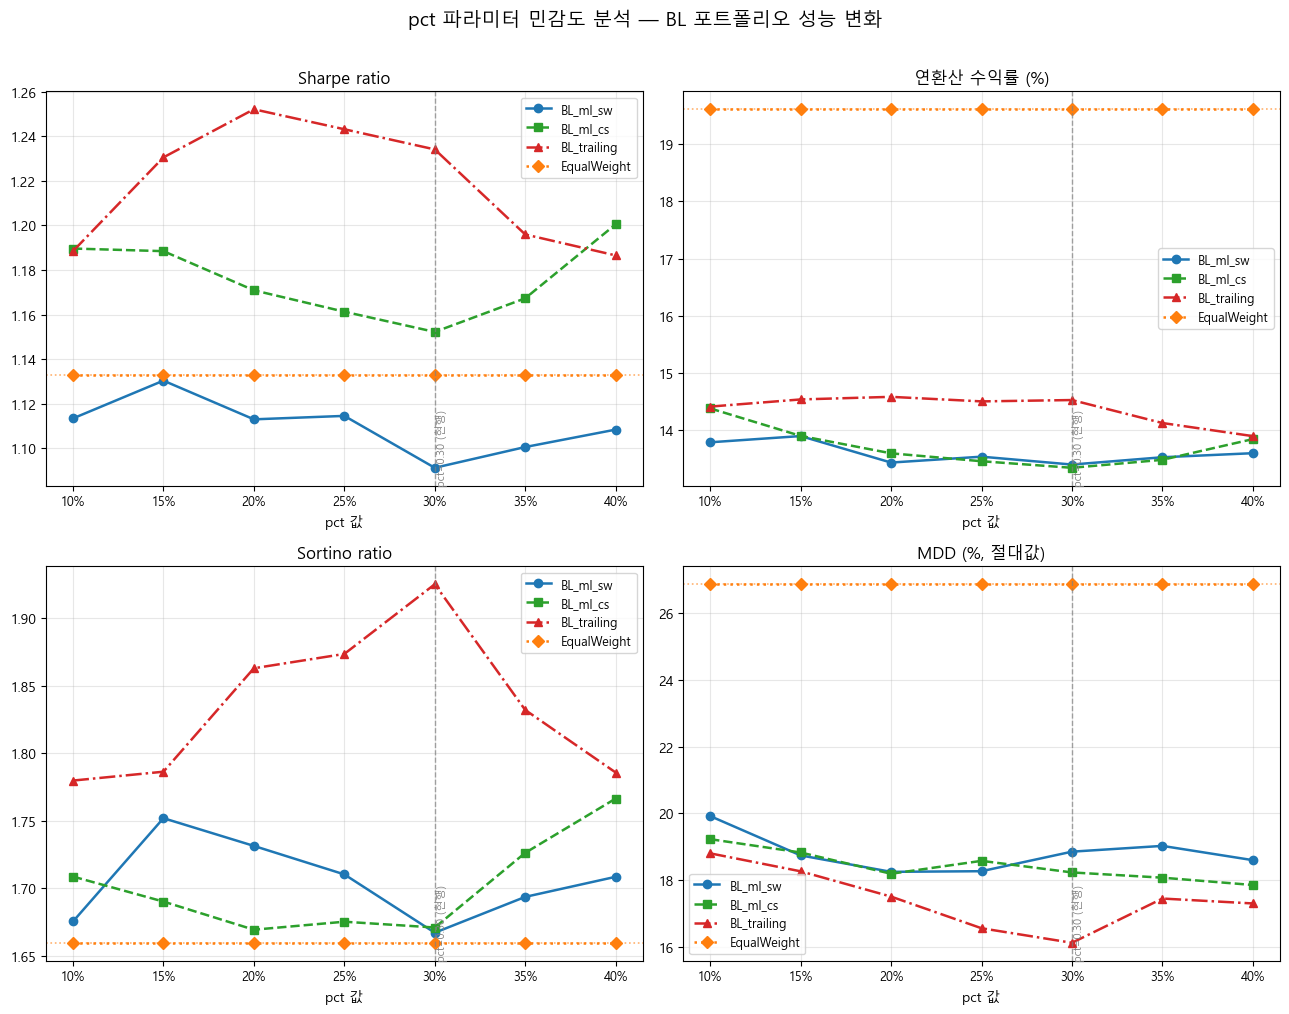

✅ fig1_metrics_vs_pct.png 저장


In [11]:
# ─── 색상 설정 ───
COLORS = {
    'BL_ml_sw':    '#1f77b4',
    'BL_ml_cs':    '#2ca02c',
    'BL_trailing': '#d62728',
    'EqualWeight': '#ff7f0e',
    'SPY':         '#8c564b',
}
LINESTYLES = {
    'BL_ml_sw':    '-',
    'BL_ml_cs':    '--',
    'BL_trailing': '-.',
    'EqualWeight': ':',
}
MARKERS = {
    'BL_ml_sw':    'o',
    'BL_ml_cs':    's',
    'BL_trailing': '^',
    'EqualWeight': 'D',
}

# ─── Figure 1: 4개 메트릭 vs pct ───
fig1, axes = plt.subplots(2, 2, figsize=(13, 10))
fig1.suptitle('pct 파라미터 민감도 분석 — BL 포트폴리오 성능 변화', fontsize=14, y=1.01)

PANELS = [
    ('sharpe',     'Sharpe ratio',         axes[0, 0]),
    ('annual_ret', '연환산 수익률 (%)',    axes[0, 1]),
    ('sortino',    'Sortino ratio',         axes[1, 0]),
    ('mdd',        'MDD (%, 절대값)',       axes[1, 1]),
]

pct_x = PCT_VALUES

for metric, title, ax in PANELS:
    for scenario in bl_scenarios:
        sub = metrics_long[
            (metrics_long['scenario'] == scenario) & (metrics_long['pct'] != 'all')
        ].sort_values('pct')
        if len(sub) == 0:
            continue

        y_vals = sub[metric].values
        # MDD는 절대값으로 표시 (음수 → 양수)
        if metric == 'mdd':
            y_vals = np.abs(y_vals)

        ax.plot(
            sub['pct'].values, y_vals,
            label=scenario,
            color=COLORS.get(scenario, 'gray'),
            linestyle=LINESTYLES.get(scenario, '-'),
            marker=MARKERS.get(scenario, 'o'),
            markersize=6,
            linewidth=1.8,
        )

    # EqualWeight 수평 기준선 (pct 무관)
    ew_val = metrics_long[metrics_long['scenario'] == 'EqualWeight'][metric].values
    if len(ew_val) > 0:
        v = abs(ew_val[0]) if metric == 'mdd' else ew_val[0]
        ax.axhline(v, color=COLORS['EqualWeight'], linestyle=':', linewidth=1.2,
                   alpha=0.6, label='_nolegend_')

    # 현행 기본값 pct=0.30 수직선
    ax.axvline(0.30, color='gray', linestyle='--', linewidth=1.0, alpha=0.7, label='_nolegend_')
    ax.text(0.30, ax.get_ylim()[0] if ax.get_ylim()[0] != ax.get_ylim()[1] else 0,
            'pct=0.30 (현행)', fontsize=8, color='gray', ha='left', va='bottom', rotation=90)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('pct 값', fontsize=10)
    ax.set_xticks(PCT_VALUES)
    ax.set_xticklabels([f'{p:.0%}' for p in PCT_VALUES], fontsize=9)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig1_metrics_vs_pct.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ fig1_metrics_vs_pct.png 저장')

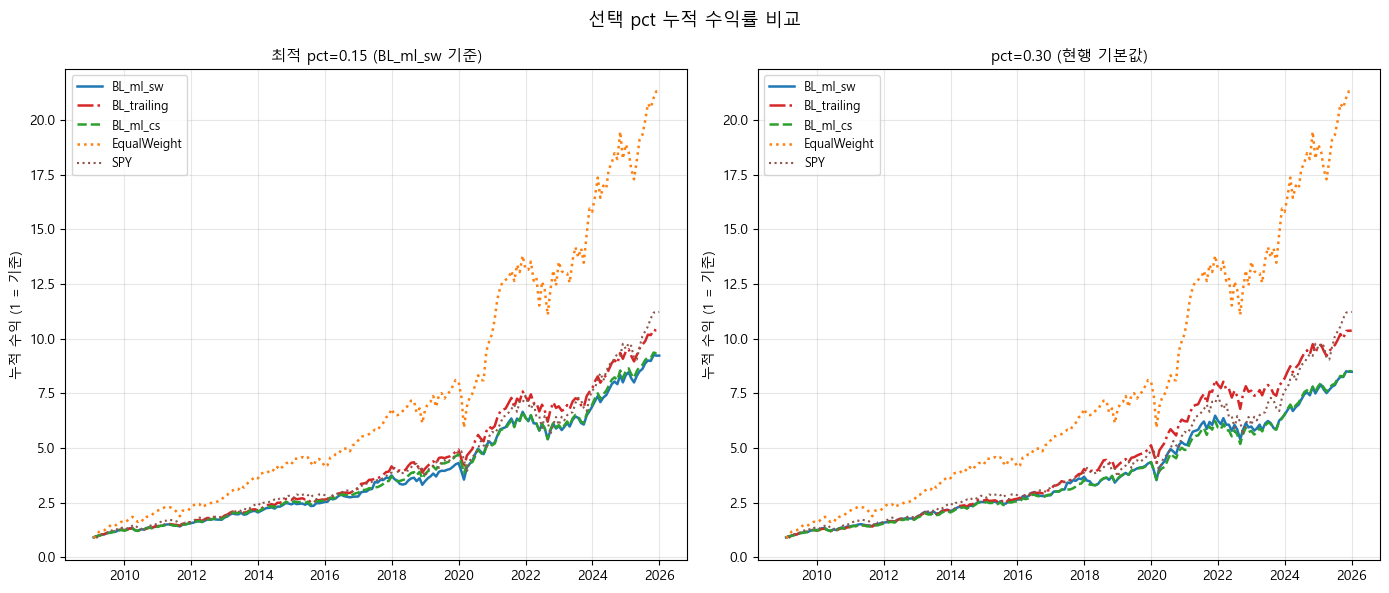

✅ fig2_cumulative_selected.png 저장


In [12]:
# ─── Figure 2: 선택 pct 누적 수익률 비교 ───
# 좌: Sharpe 기준 최적 pct (BL_ml_sw 또는 BL_trailing 기준)
# 우: 기본값 pct=0.30

ref_scenario = 'BL_ml_sw' if 'BL_ml_sw' in optimal_pct else 'BL_trailing'
best_pct = optimal_pct[ref_scenario]['pct'] if ref_scenario in optimal_pct else 0.20
best_pct_label = f'최적 pct={best_pct:.2f} ({ref_scenario} 기준)'

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle('선택 pct 누적 수익률 비교', fontsize=13)

for ax, pct_val, title_suffix in [
    (axes2[0], best_pct, best_pct_label),
    (axes2[1], 0.30,     'pct=0.30 (현행 기본값)'),
]:
    port_at_pct = fair_returns.get(pct_val, {})
    for scenario, rets in port_at_pct.items():
        if len(rets) == 0:
            continue
        cum = (1 + rets).cumprod()
        ax.plot(cum.index, cum.values,
                label=scenario,
                color=COLORS.get(scenario, 'gray'),
                linestyle=LINESTYLES.get(scenario, '-'),
                linewidth=1.8)

    # SPY 누적 (별도)
    spy_cum = (1 + spy_fair).cumprod()
    ax.plot(spy_cum.index, spy_cum.values, label='SPY',
            color=COLORS['SPY'], linestyle=':', linewidth=1.5)

    ax.set_title(title_suffix, fontsize=11)
    ax.set_ylabel('누적 수익 (1 = 기준)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig2_cumulative_selected.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ fig2_cumulative_selected.png 저장')

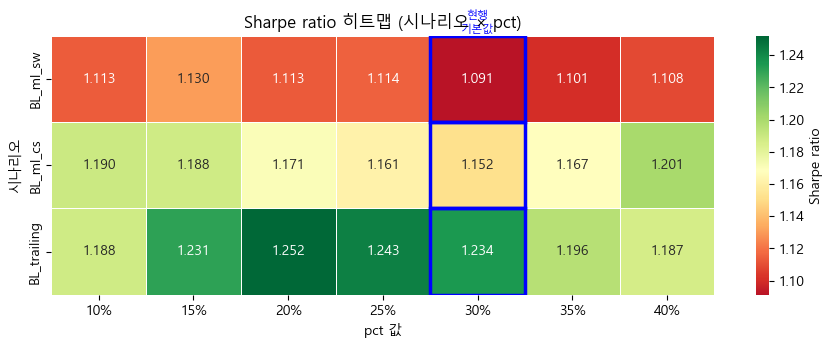

✅ fig3_heatmap_sharpe.png 저장


In [13]:
# ─── Figure 3: Sharpe ratio 히트맵 ───
heatmap_scenarios = [s for s in ['BL_ml_sw', 'BL_ml_cs', 'BL_trailing']
                     if s in metrics_long['scenario'].values]

pivot_heatmap = metrics_long[
    (metrics_long['scenario'].isin(heatmap_scenarios)) &
    (metrics_long['pct'] != 'all')
].pivot_table(index='scenario', columns='pct', values='sharpe')

# 행 순서 고정
pivot_heatmap = pivot_heatmap.reindex([s for s in heatmap_scenarios
                                        if s in pivot_heatmap.index])
pivot_heatmap.columns = [f'{c:.0%}' for c in pivot_heatmap.columns]

fig3, ax3 = plt.subplots(figsize=(9, max(3, len(heatmap_scenarios) * 1.2)))
sns.heatmap(
    pivot_heatmap,
    ax=ax3,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',      # 낮은=빨강, 높은=초록
    center=pivot_heatmap.values[~np.isnan(pivot_heatmap.values)].mean()
    if not np.all(np.isnan(pivot_heatmap.values)) else 0,
    linewidths=0.5,
    cbar_kws={'label': 'Sharpe ratio'},
)
ax3.set_title('Sharpe ratio 히트맵 (시나리오 × pct)', fontsize=12)
ax3.set_xlabel('pct 값', fontsize=10)
ax3.set_ylabel('시나리오', fontsize=10)

# pct=30% 열 강조 (현행 기본값)
col_30_idx = list(pivot_heatmap.columns).index('30%') if '30%' in pivot_heatmap.columns else None
if col_30_idx is not None:
    for row_idx in range(len(pivot_heatmap)):
        ax3.add_patch(plt.Rectangle(
            (col_30_idx, row_idx), 1, 1,
            fill=False, edgecolor='blue', linewidth=2.5,
        ))
    ax3.text(col_30_idx + 0.5, -0.3, '현행\n기본값', fontsize=8, ha='center',
             color='blue', va='top')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig3_heatmap_sharpe.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ fig3_heatmap_sharpe.png 저장')

## §8. 결과 저장

In [14]:
import json

# 메트릭 전체 (롱 포맷)
save_cols = ['pct', 'scenario', 'sharpe', 'annual_ret', 'ann_vol',
             'sortino', 'mdd', 'cagr', 'n_months']
metrics_long_save = metrics_long[[c for c in save_cols if c in metrics_long.columns]]
metrics_long_save.to_csv(OUT_DIR / 'pct_metrics_long.csv', index=False, encoding='utf-8-sig')
print('✅ pct_metrics_long.csv 저장')

# Sharpe 피벗 (시나리오 × pct)
pivot_save = metrics_long[metrics_long['pct'] != 'all'].pivot_table(
    index='scenario', columns='pct', values='sharpe'
)
pivot_save.to_csv(OUT_DIR / 'pct_metrics_sharpe_pivot.csv', encoding='utf-8-sig')
print('✅ pct_metrics_sharpe_pivot.csv 저장')

# summary.json
summary = {
    'experiment': 'pct_sensitivity',
    'pct_values': PCT_VALUES,
    'baseline_pct': base_pct,
    'fair_comparison_scenario': base_scenario,
    'fair_date_range': [
        str(common_dates[0].date()),
        str(common_dates[-1].date()),
    ],
    'n_months': int(len(common_dates)),
    'optimal_pct_by_scenario': {
        s: {k: (round(v, 4) if isinstance(v, float) else v) for k, v in info.items()}
        for s, info in optimal_pct.items()
    },
    'spy_baseline': {
        k: (round(float(v), 4) if isinstance(v, (int, float)) and not pd.isna(v) else None)
        for k, v in spy_metrics.items()
        if k not in ('pct', 'scenario')
    },
    'has_cs': bool(HAS_CS),
}
with open(OUT_DIR / 'summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print('✅ summary.json 저장')

print(f'\n=== Phase 3 Step 6 — pct 민감도 실험 완료 ===')
print(f'출력 경로: {OUT_DIR}')
print('다음 단계: 04_compare_stockwise_vs_cross.ipynb (03 노트북 실행 후)')

✅ pct_metrics_long.csv 저장
✅ pct_metrics_sharpe_pivot.csv 저장
✅ summary.json 저장

=== Phase 3 Step 6 — pct 민감도 실험 완료 ===
출력 경로: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\06_pct_sensitivity
다음 단계: 04_compare_stockwise_vs_cross.ipynb (03 노트북 실행 후)
